In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

In [53]:
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False


In [54]:
news = pd.read_csv("news.csv", encoding="latin1")

print("News dataset shape:", news.shape)
print("\nNews columns:")
print(news.columns.tolist())
print("\nFirst 5 rows:")
print(news.head())

News dataset shape: (3349, 189)

News columns:
['Title', 'Date', 'Description', 'Author', 'Content', 'Keywords', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnam

In [55]:
drop_columns = [
    "Description", "Author", "Content", "Keywords",
    "Unnamed: 6", "Unnamed: 7", "Unnamed: 8", "Unnamed: 9",
    "Unnamed: 179", "Unnamed: 180", "Unnamed: 181",
    "Unnamed: 182", "Unnamed: 183", "Unnamed: 184",
    "Unnamed: 185", "Unnamed: 186", "Unnamed: 187",
    "Unnamed: 188"
]

In [56]:
news = news.drop(columns=drop_columns, errors="ignore")

In [57]:
if "Date" in news.columns and "Title" in news.columns:
    news = news[["Date", "Title"]]
else:
    news = news.iloc[:, :2]
    news.columns = ["Date", "Title"]

In [58]:
print("\nMissing values before cleaning:")
print(news.isnull().sum())


Missing values before cleaning:
Date     0
Title    0
dtype: int64


In [59]:
news = news.dropna(subset=["Date", "Title"])
news = news.drop_duplicates()
news["Title"] = news["Title"].astype(str).str.strip()

In [60]:
print("\nNews shape after cleaning:", news.shape)
print(news.head())


News shape after cleaning: (3348, 2)
         Date                                              Title
0  08-07-2025  Aurobindo Pharma, Dr Reddy's, Lupin, other pha...
1  18-07-2025  Bharti Airtel share price falls 1.53%; stock a...
2  09-07-2025  Indian Oil and Adani Gas JV plans $161 million...
3  03-06-2025  Cipla Shares Fall in Today's Trading Session A...
4  07-02-2025  Here are the sectors and stocks in focus amids...


In [61]:
grouped_news = (
    news.groupby("Date")["Title"]
        .apply(list)
        .reset_index()
)

In [62]:
grouped_news["Date"] = pd.to_datetime(
    grouped_news["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [63]:
grouped_news = grouped_news.dropna(subset=["Date"])

In [64]:
print("\nGrouped news:")
print(grouped_news.head())
print("Grouped news shape:", grouped_news.shape)


Grouped news:
        Date                                              Title
1 2025-04-01  [Indian companies gear up for nuclear expansio...
2 2025-05-01  [Adani Enterprises Q4 Results: Net profit rise...
3 2025-06-01  [Trade Spotlight: How should you trade CDSL, M...
4 2025-07-01  [PSU bank stocks snap 5-day gaining streak ami...
5 2025-08-01  [ITC share price gain 1.27% in friday's tradin...
Grouped news shape: (173, 2)


In [65]:
stock = pd.read_csv("nifty50.csv", encoding="cp1252")

In [66]:
print("\nNIFTY50 dataset shape:", stock.shape)
print(stock.head())
print(stock.columns.tolist())


NIFTY50 dataset shape: (142, 7)
      ï»¿Date      Open      High       Low     Close   Shares Traded   \
0  29-AUG-2025  24466.70  24572.45  24404.70  24426.85       325543583   
1  28-AUG-2025  24695.80  24702.65  24481.60  24500.90       326601486   
2  26-AUG-2025  24899.50  24919.65  24689.60  24712.05       750473927   
3  25-AUG-2025  24949.15  25021.55  24894.35  24967.75       213032133   
4  22-AUG-2025  25064.15  25084.85  24859.15  24870.10       210165384   

   Turnover (â‚¹ Cr)  
0           26796.69  
1           29371.67  
2           47068.20  
3           19871.25  
4           19655.78  
['ï»¿Date ', 'Open ', 'High ', 'Low ', 'Close ', 'Shares Traded ', 'Turnover (â‚¹ Cr)']


In [67]:
expected_stock_columns = [
    "date", "open", "high", "low", "close",
    "shares_traded", "turnover_cr"
]

In [68]:
if len(stock.columns) == len(expected_stock_columns):
    stock.columns = expected_stock_columns
else:
    rename_map = {col: col.strip().lower() for col in stock.columns}
    stock = stock.rename(columns=rename_map)

    required = ["date", "open", "high", "low", "close"]
    missing_required = [col for col in required if col not in stock.columns]

    if missing_required:
        raise ValueError(
            f"Could not identify required stock columns: {missing_required}"
        )

    for col in ["shares_traded", "turnover_cr"]:
        if col not in stock.columns:
            stock[col] = np.nan

    stock = stock[
        required + ["shares_traded", "turnover_cr"]
    ]


In [69]:
for col in [
    "open", "high", "low", "close",
    "shares_traded", "turnover_cr"
]:
    stock[col] = pd.to_numeric(stock[col], errors="coerce")

stock["date"] = pd.to_datetime(
    stock["date"],
    dayfirst=True,
    errors="coerce"
)

/tmp/ipykernel_490/1011011022.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  stock["date"] = pd.to_datetime(


In [70]:
stock = stock.dropna(
    subset=["date", "open", "high", "low", "close"]
)

stock = stock.sort_values("date").reset_index(drop=True)

print("\nClean stock shape:", stock.shape)
print(stock.head())


Clean stock shape: (142, 7)
        date      open      high       low     close  shares_traded  \
0 2025-02-01  23528.60  23632.45  23318.30  23482.15      287703637   
1 2025-02-03  23319.35  23381.60  23222.00  23361.05      347241171   
2 2025-02-04  23509.90  23762.75  23423.15  23739.25      376742506   
3 2025-02-05  23801.75  23807.30  23680.45  23696.30      267014345   
4 2025-02-06  23761.95  23773.55  23556.25  23603.35      306978683   

   turnover_cr  
0     25741.04  
1     32019.13  
2     35974.30  
3     25806.44  
4     30885.59  


In [71]:
merged = pd.merge(
    stock,
    grouped_news,
    left_on="date",
    right_on="Date",
    how="inner"
)

In [72]:
merged = merged.drop(columns=["Date"])
merged = merged.sort_values("date").reset_index(drop=True)

In [73]:
print("\nMerged dataset shape:", merged.shape)
print(merged.head())
print("\nMissing values after merge:")
print(merged.isnull().sum())


Merged dataset shape: (132, 8)
        date      open      high       low     close  shares_traded  \
0 2025-02-07  23649.50  23694.50  23443.20  23559.95      368092482   
1 2025-02-10  23543.80  23568.60  23316.30  23381.60      225529166   
2 2025-02-11  23383.55  23390.05  22986.65  23071.80      267969979   
3 2025-02-12  23050.80  23144.70  22798.35  23045.25      279656513   
4 2025-02-13  23055.75  23235.50  22992.20  23031.40      265706855   

   turnover_cr                                              Title  
0     30042.00  [Here are the sectors and stocks in focus amid...  
1     21254.72  [Apollo Hospitals Q3 Results: Net profit up 51...  
2     27191.96  [Apollo Hospitals shares plunge 7% amid heavy ...  
3     26989.94  [Trent Standalone December 2024 Net Sales at R...  
4     25218.86  [Trade Spotlight: How should you trade Bajaj F...  

Missing values after merge:
date             0
open             0
high             0
low              0
close            0
shares_tr

In [74]:
merged["movement"] = merged["close"] - merged["open"]
merged["target"] = (merged["movement"] > 0).astype(int)

In [75]:
print("\nTarget distribution:")
print(merged["target"].value_counts())


Target distribution:
target
0    67
1    65
Name: count, dtype: int64


In [76]:
positive_words = [
'gain', 'gains', 'gained', 'gainer', 'gainers',
    'growth', 'grow', 'grew', 'growing', 'grown',
    'profit', 'profits', 'profitable', 'profitability',
    'rise', 'rises', 'rising', 'risen', 'rose',
    'rally', 'rallied', 'rallying', 'rallies',
    'surge', 'surges', 'surged', 'surging',
    'bullish', 'bull', 'bull run',
    'record', 'record-high', 'record high',
    'all-time high', 'peak', 'peaked',
    'advance', 'advanced', 'advancing', 'advances',
    'uptrend', 'upward', 'upside',
    'upside potential', 'breakout', 'breakthrough',
    'rebound', 'rebounded', 'rebounding',
    'recovery', 'recover', 'recovered', 'recovering',
    'revival', 'revive', 'revived',
    'strength', 'strong', 'stronger', 'strongest',
    'stability', 'stable', 'stabilize', 'stabilized',
    'resilient', 'resilience',
    'momentum', 'positive momentum',
    'buying interest', 'buying support',
    'buying spree', 'buying pressure',

    'earnings growth', 'revenue growth',
    'sales growth', 'profit growth',
    'profit surge', 'profit rises',
    'profit jumps', 'profit boost',
    'earnings beat', 'earnings beats',
    'revenue beat', 'sales beat',
    'beat estimates', 'beat expectations',
    'beats expectations',
    'better-than-expected',
    'above expectations', 'strong earnings',
    'strong results', 'robust earnings',
    'robust growth', 'record earnings',
    'record revenue', 'record profit',
    'record sales', 'higher revenue',
    'higher profit', 'higher earnings',
    'higher margins', 'margin expansion',
    'margin improvement', 'improved margins',
    'improved earnings', 'improved revenue',
    'improved profitability',

    'upgrade', 'upgraded', 'upgrades',
    'buy', 'buy rating', 'buy recommendation',
    'strong buy', 'outperform', 'outperformed',
    'overweight', 'positive outlook',
    'bullish outlook', 'optimistic',
    'optimism', 'confidence',
    'investor confidence', 'analyst upgrade',
    'target raised', 'price target raised',
    'higher target', 'favorable outlook',
    'positive sentiment', 'positive trend',

    'investment', 'investments', 'invested',
    'investor interest', 'capital inflow',
    'fund inflow', 'fund inflows',
    'foreign inflow', 'fii inflow',
    'dii buying', 'institutional buying',
    'institutional inflow',
    'strong demand', 'demand growth',
    'rising demand', 'increased demand',
    'consumer demand', 'market demand',

    'expansion', 'expand', 'expanded',
    'expanding', 'business expansion',
    'capacity expansion', 'production increase',
    'production growth', 'output growth',
    'higher production', 'new orders',
    'order growth', 'strong orders',
    'large order', 'major order',
    'contract win', 'contract wins',
    'new contract', 'business win',

    'dividend', 'dividends', 'dividend increase',
    'higher dividend', 'special dividend',
    'bonus', 'bonus issue', 'stock split',
    'buyback', 'share buyback', 'repurchase',
    'debt reduction', 'debt repayment',
    'lower debt', 'reduced debt',
    'deleveraging', 'cash generation',
    'strong cash flow', 'positive cash flow',

    'innovation', 'innovative', 'launch',
    'launched', 'launches', 'new product',
    'product growth', 'product success',
    'market share gain', 'market share growth',
    'leadership', 'market leader',
    'competitive advantage', 'strategic advantage',
    'partnership', 'partnerships',
    'collaboration', 'acquisition',
    'acquisitions', 'merger',
    'merger approval', 'deal win',
    'deal wins', 'strategic deal',

    'approval', 'approved', 'regulatory approval',
    'clearance', 'cleared', 'positive development',
    'favorable', 'favourable',
    'success', 'successful', 'successfully',
    'improvement', 'improved',
    'efficient', 'efficiency',
    'cost reduction', 'cost savings',
    'operating efficiency', 'productivity',
    'higher productivity', 'business confidence'
]


In [77]:
negative_words = [
# Basic negative terms
    'loss', 'losses', 'lost', 'lose', 'losing',
    'decline', 'declines', 'declined', 'declining',
    'fall', 'falls', 'fell', 'falling',
    'drop', 'drops', 'dropped', 'dropping',
    'slump', 'slumps', 'slumped', 'slumping',
    'crash', 'crashes', 'crashed', 'crashing',
    'plunge', 'plunges', 'plunged', 'plunging',
    'plummet', 'plummets', 'plummeted', 'plummeting',
    'collapse', 'collapses', 'collapsed', 'collapsing',
    'nosedive', 'nosedived',
    'tumble', 'tumbles', 'tumbled', 'tumbling',

    # Market / price negative
    'bearish', 'bear market',
    'downtrend', 'downward',
    'downside', 'downside risk',
    'selling pressure',
    'selling spree',
    'heavy selling',
    'panic selling',
    'profit booking',
    'market weakness',
    'weakness',
    'weak',
    'weaker',
    'weakest',
    'volatility',
    'volatile',
    'market turmoil',
    'market turmoil',
    'market stress',
    'market uncertainty',
    'uncertainty',
    'uncertain',
    'correction',
    'market correction',
    'sharp correction',
    'deep correction',
    'breakdown',
    'failed breakout',

    # Corporate negative
    'profit decline',
    'profit drop',
    'profit fall',
    'profit plunge',
    'profit slump',
    'profit warning',
    'profit miss',
    'earnings miss',
    'earnings decline',
    'earnings drop',
    'earnings fall',
    'revenue decline',
    'revenue drop',
    'revenue fall',
    'sales decline',
    'sales drop',
    'sales fall',
    'lower revenue',
    'lower profit',
    'lower earnings',
    'lower margins',
    'margin contraction',
    'margin pressure',
    'weak earnings',
    'weak results',
    'poor results',
    'disappointing results',
    'disappointing earnings',
    'underperformance',
    'underperformed',
    'missed estimates',
    'missed expectations',
    'below expectations',
    'below estimates',
    'worse-than-expected',

    # Financial problems
    'default',
    'defaults',
    'defaulted',
    'bankruptcy',
    'bankrupt',
    'insolvency',
    'insolvent',
    'debt crisis',
    'debt burden',
    'high debt',
    'rising debt',
    'debt stress',
    'credit risk',
    'credit downgrade',
    'credit loss',
    'bad debt',
    'bad loan',
    'bad loans',
    'npa',
    'npas',
    'non-performing asset',
    'non-performing assets',
    'write-off',
    'write-offs',
    'loan loss',
    'loan losses',
    'loan default',

    # Analyst / rating negative
    'downgrade',
    'downgraded',
    'downgrades',
    'sell rating',
    'sell recommendation',
    'strong sell',
    'underweight',
    'underperform',
    'underperformed',
    'analyst downgrade',
    'target cut',
    'target lowered',
    'price target cut',
    'price target lowered',
    'lower target',
    'negative outlook',
    'bearish outlook',
    'pessimistic',
    'pessimism',
    'investor concern',
    'investor concerns',

    # Economic negative
    'recession',
    'recession risk',
    'economic slowdown',
    'slowdown',
    'economic weakness',
    'weak economy',
    'stagflation',
    'inflation',
    'high inflation',
    'rising inflation',
    'inflation pressure',
    'inflationary pressure',
    'rate hike',
    'rate hikes',
    'interest rate hike',
    'higher interest rates',
    'monetary tightening',
    'tightening',
    'hawkish',
    'hawkish stance',
    'policy uncertainty',
    'economic uncertainty',

    # Employment / business negative
    'layoffs',
    'layoff',
    'job cuts',
    'job losses',
    'workforce reduction',
    'retrenchment',
    'downsizing',
    'cost cutting',
    'plant closure',
    'store closure',
    'business closure',
    'shutdown',
    'production halt',
    'production cut',
    'capacity reduction',

    # Institutional selling
    'fii selling',
    'fii outflow',
    'fii outflows',
    'dii selling',
    'institutional selling',
    'foreign selling',
    'foreign outflow',
    'capital outflow',
    'fund outflow',
    'fund outflows',
    'investor outflow',

    # Risk / concern
    'risk',
    'risks',
    'risky',
    'concern',
    'concerns',
    'warning',
    'warnings',
    'threat',
    'threats',
    'danger',
    'dangerous',
    'negative',
    'negatively',
    'adverse',
    'adversely',
    'damage',
    'damaged',
    'damaging',
    'pressure',
    'pressured',
    'stress',
    'stressed',
    'distress',
    'financial distress',

    # Legal / regulatory problems
    'fraud',
    'fraudulent',
    'scam',
    'scandal',
    'investigation',
    'probe',
    'regulatory action',
    'regulatory concern',
    'legal action',
    'lawsuit',
    'litigation',
    'penalty',
    'penalties',
    'fine',
    'fined',
    'violation',
    'violations',
    'compliance issue',

    # Operational problems
    'disruption',
    'disruptions',
    'disrupted',
    'supply disruption',
    'supply shortage',
    'shortage',
    'shortfall',
    'production decline',
    'production loss',
    'operational loss',
    'operational issue',
    'technical issue',
    'system failure',
    'failure',
    'failed',
    'delay',
    'delayed',
    'cancellation',
    'cancelled',
    'recall',
    'product recall',

    # Market-specific negative terms
    'lower circuit',
    'upper circuit failure',
    'circuit breaker',
    'bearish trend',
    'bearish sentiment',
    'negative sentiment',
    'risk-off',
    'risk aversion',
    'flight to safety',
    'market selloff',
    'sell-off',
    'selloff',
    'sharp fall',
    'sharp decline',
    'sharp drop',
    'sharp plunge',
    'heavy losses',
    'record loss',
    'record losses',
    'multi-year low',
    '52-week low',
    'all-time low',
    'fresh low',
    'new low'
]


In [78]:
positive_words = list(dict.fromkeys(
    word.lower().strip() for word in positive_words
))

In [79]:
negative_words = list(dict.fromkeys(
    word.lower().strip() for word in negative_words
))

In [80]:
print("\nPositive terms:", len(positive_words))
print("Negative terms:", len(negative_words))


Positive terms: 231
Negative terms: 289


In [81]:
def sentiment_score(text):
    text = str(text).lower()
    score = 0

    for word in positive_words:
        score += text.count(word)

    for word in negative_words:
        score -= text.count(word)

    return score

In [82]:

merged["sentiment_score"] = merged["Title"].apply(sentiment_score)

print("\nSentiment score summary:")
print(merged["sentiment_score"].describe())


Sentiment score summary:
count    132.000000
mean       8.325758
std       11.743113
min      -22.000000
25%        1.000000
50%        7.000000
75%       15.000000
max       42.000000
Name: sentiment_score, dtype: float64


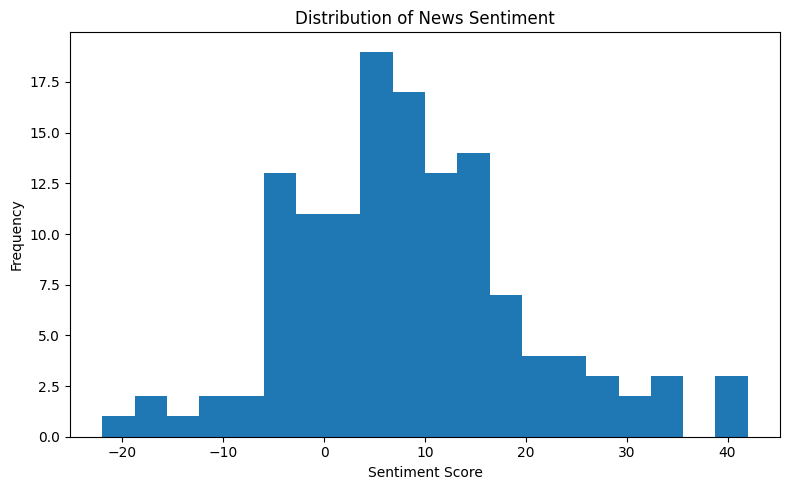

In [83]:
plt.figure(figsize=(8, 5))
plt.hist(merged["sentiment_score"], bins=20)
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Distribution of News Sentiment")
plt.tight_layout()
plt.show()

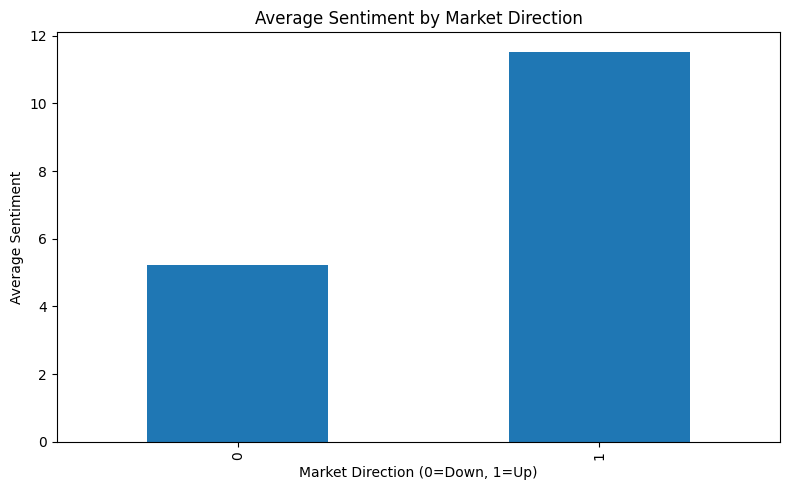

In [84]:
plt.figure(figsize=(8, 5))
merged.groupby("target")["sentiment_score"].mean().plot(kind="bar")
plt.xlabel("Market Direction (0=Down, 1=Up)")
plt.ylabel("Average Sentiment")
plt.title("Average Sentiment by Market Direction")
plt.tight_layout()
plt.show()

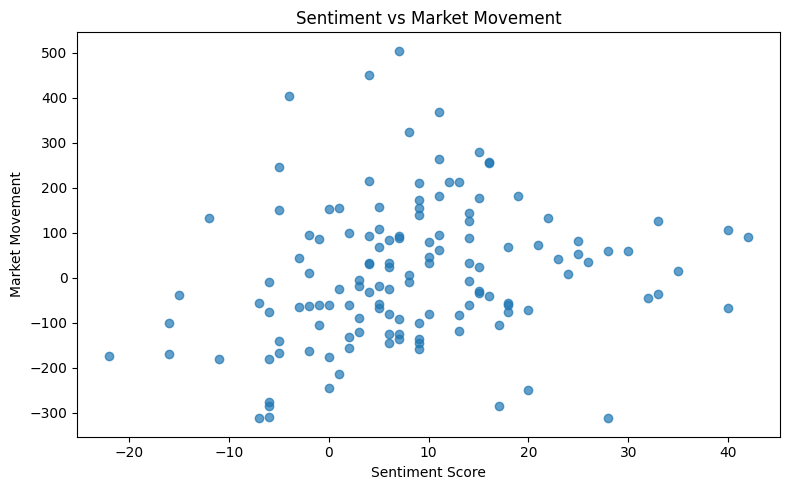

In [85]:
plt.figure(figsize=(8, 5))
plt.scatter(
    merged["sentiment_score"],
    merged["movement"],
    alpha=0.7
)
plt.xlabel("Sentiment Score")
plt.ylabel("Market Movement")
plt.title("Sentiment vs Market Movement")
plt.tight_layout()
plt.show()

In [86]:
def predict_market(score):
    if score > 0:
        return "UP"
    elif score < 0:
        return "DOWN"
    return "NEUTRAL"

merged["prediction"] = merged["sentiment_score"].apply(
    predict_market
)

In [87]:
def binary_prediction(score):
    return int(score > 0)

merged["prediction_binary"] = merged["sentiment_score"].apply(
    binary_prediction
)

In [88]:
part_a_accuracy = accuracy_score(
    merged["target"],
    merged["prediction_binary"]
)

In [89]:
part_a_baseline = (
    merged["target"] == merged["target"].mode()[0]
).mean()

In [90]:
print("\n========== PART A ==========")
print(
    "Same-day sentiment accuracy:",
    round(part_a_accuracy * 100, 2),
    "%"
)


========== PART A ==========
Same-day sentiment accuracy: 59.85 %


In [91]:
print(
    "Majority baseline:",
    round(part_a_baseline * 100, 2),
    "%"
)

Majority baseline: 50.76 %


In [92]:
merged.to_csv("final_project_dataset.csv", index=False)
print("Saved: final_project_dataset.csv")

Saved: final_project_dataset.csv


In [93]:
ml_df = merged.copy()
ml_df = ml_df.sort_values("date").reset_index(drop=True)

In [94]:
ml_df["next_day_target"] = ml_df["target"].shift(-1)

In [95]:
ml_df = ml_df.dropna(
    subset=["next_day_target"]
).reset_index(drop=True)

In [96]:
ml_df["next_day_target"] = (
    ml_df["next_day_target"].astype(int)
)

In [97]:
ml_df["sentiment_ma3"] = (
    ml_df["sentiment_score"].rolling(3).mean()
)

In [98]:
ml_df["sentiment_ma7"] = (
    ml_df["sentiment_score"].rolling(7).mean()
)

In [99]:
ml_df["sentiment_std3"] = (
    ml_df["sentiment_score"].rolling(3).std()
)


In [100]:
ml_df["movement_lag1"] = (
    ml_df["movement"].shift(1)
)

In [101]:
ml_df["movement_lag2"] = (
    ml_df["movement"].shift(2)
)

In [102]:
ml_df["volume_change"] = (
    ml_df["shares_traded"].pct_change()
)


In [103]:
ml_df["high_low_spread"] = (
    (ml_df["high"] - ml_df["low"])
    / ml_df["open"]
) * 100

In [104]:
ml_df = ml_df.replace(
    [np.inf, -np.inf],
    np.nan
)

In [105]:
ml_df = ml_df.dropna().reset_index(drop=True)

In [106]:
print("\nML dataset shape:", ml_df.shape)


ML dataset shape: (125, 21)


In [107]:
feature_cols = [
    "sentiment_score",
    "sentiment_ma3",
    "sentiment_ma7",
    "sentiment_std3",
    "movement_lag1",
    "movement_lag2",
    "volume_change",
    "high_low_spread"
]

In [108]:
X = ml_df[feature_cols]
y = ml_df["next_day_target"]

In [109]:
split_idx = int(len(ml_df) * 0.80)

In [110]:
X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

In [111]:
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

In [112]:
print("\n========== TRAIN / TEST ==========")
print("Train days:", len(X_train))
print("Test days:", len(X_test))


========== TRAIN / TEST ==========
Train days: 100
Test days: 25


In [113]:
majority_class = y_train.mode()[0]

In [114]:
majority_baseline = (
    y_test == majority_class
).mean()


In [115]:
print(
    "Majority-class baseline:",
    round(majority_baseline * 100, 2),
    "%"
)

Majority-class baseline: 44.0 %


In [116]:
scaler = StandardScaler()

In [117]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [118]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [119]:
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [120]:
y_pred_lr = log_reg.predict(X_test_scaled)

In [121]:
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

In [122]:
print("\n========== LOGISTIC REGRESSION ==========")
print(
    "Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)


========== LOGISTIC REGRESSION ==========
Accuracy: 36.0 %


In [123]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Down", "Up"],
    zero_division=0
))

              precision    recall  f1-score   support

        Down       0.38      0.21      0.27        14
          Up       0.35      0.55      0.43        11

    accuracy                           0.36        25
   macro avg       0.36      0.38      0.35        25
weighted avg       0.37      0.36      0.34        25



In [124]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

In [125]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=10, n_estimators=300,
                       random_state=42)

In [126]:
y_pred_rf = rf.predict(X_test)

In [127]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

In [128]:
print("\n========== RANDOM FOREST ==========")
print(
    "Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)


========== RANDOM FOREST ==========
Accuracy: 36.0 %


In [129]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Down", "Up"],
    zero_division=0
))

              precision    recall  f1-score   support

        Down       0.38      0.21      0.27        14
          Up       0.35      0.55      0.43        11

    accuracy                           0.36        25
   macro avg       0.36      0.38      0.35        25
weighted avg       0.37      0.36      0.34        25



In [130]:
xgb_accuracy = np.nan
y_pred_xgb = None

In [131]:
if XGBOOST_AVAILABLE:
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)

    xgb_accuracy = accuracy_score(
        y_test,
        y_pred_xgb
    )

    print("\n========== XGBOOST ==========")
    print(
        "Accuracy:",
        round(xgb_accuracy * 100, 2),
        "%"
    )

    print(classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Down", "Up"],
        zero_division=0
    ))
else:
    print(
        "\nXGBoost is not installed. "
        "Run: pip install xgboost"
    )



========== XGBOOST ==========
Accuracy: 40.0 %
              precision    recall  f1-score   support

        Down       0.44      0.29      0.35        14
          Up       0.38      0.55      0.44        11

    accuracy                           0.40        25
   macro avg       0.41      0.42      0.40        25
weighted avg       0.41      0.40      0.39        25



In [132]:
results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        majority_baseline,
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

In [133]:
results["Accuracy (%)"] = results["Accuracy"] * 100

print("\n========== MODEL COMPARISON ==========")
print(results[["Model", "Accuracy (%)"]].round(2))


========== MODEL COMPARISON ==========
                 Model  Accuracy (%)
0    Majority Baseline          44.0
1  Logistic Regression          36.0
2        Random Forest          36.0
3              XGBoost          40.0


In [134]:
tscv = TimeSeriesSplit(n_splits=5)

In [135]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [5, 10, 20]
}

In [136]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring="accuracy",
    n_jobs=-1
)

In [137]:
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

In [138]:
print("\n========== HYPERPARAMETER TUNING ==========")
print("Best parameters:")
print(grid_search.best_params_)


========== HYPERPARAMETER TUNING ==========
Best parameters:
{'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 300}


In [139]:
print(
    "Best CV accuracy:",
    round(grid_search.best_score_ * 100, 2),
    "%"
)




Best CV accuracy: 53.75 %


In [140]:
y_pred_best = best_rf.predict(X_test)

In [141]:
tuned_accuracy = accuracy_score(
    y_test,
    y_pred_best
)


In [142]:

print(
    "Tuned Random Forest test accuracy:",
    round(tuned_accuracy * 100, 2),
    "%"
)

Tuned Random Forest test accuracy: 40.0 %


In [143]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)


In [144]:
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 3 11]
 [ 4  7]]


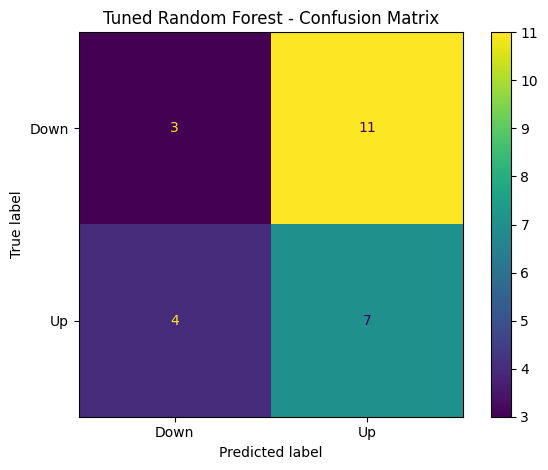

In [145]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Down", "Up"]
)

disp.plot()
plt.title("Tuned Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [146]:
test_df = ml_df.iloc[split_idx:].copy().reset_index(
    drop=True
)

test_df["pred"] = y_pred_best

In [147]:
test_df["next_day_return_pct"] = (
    (
        test_df["close"].shift(-1)
        - test_df["close"]
    )
    / test_df["close"]
) * 100

In [148]:
test_df["strategy_return"] = np.where(
    test_df["pred"] == 1,
    test_df["next_day_return_pct"],
    0
)

In [149]:
test_df["cumulative_strategy"] = (
    1 + test_df["strategy_return"].fillna(0) / 100
).cumprod()

In [150]:
test_df["cumulative_market"] = (
    1 + test_df["next_day_return_pct"].fillna(0) / 100
).cumprod()

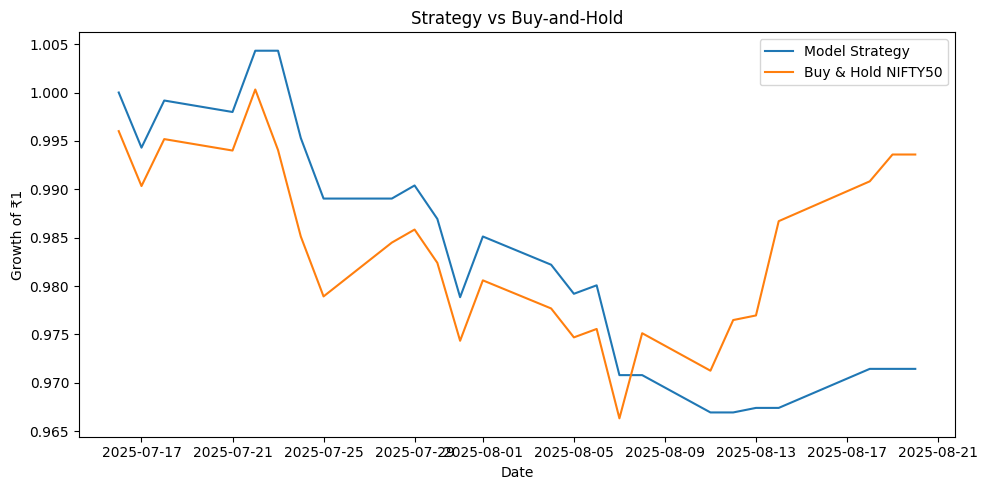

In [151]:
plt.figure(figsize=(10, 5))

plt.plot(
    test_df["date"],
    test_df["cumulative_strategy"],
    label="Model Strategy"
)
plt.plot(
    test_df["date"],
    test_df["cumulative_market"],
    label="Buy & Hold NIFTY50"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.title("Strategy vs Buy-and-Hold")
plt.legend()
plt.tight_layout()
plt.show()


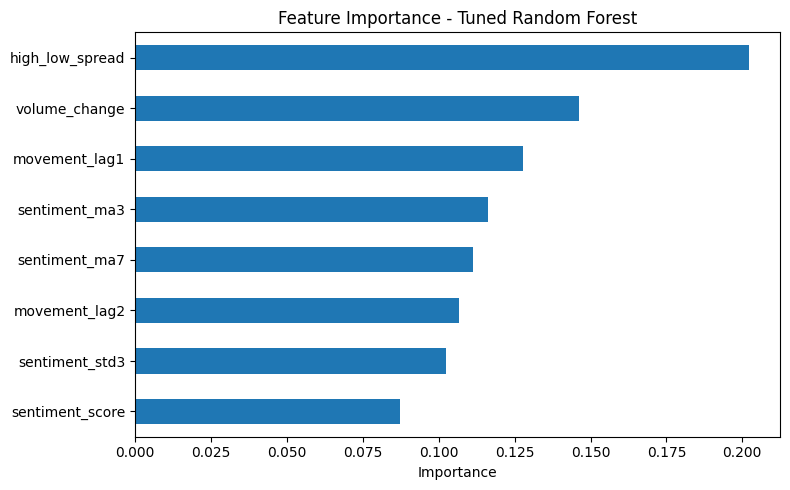

In [152]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=feature_cols
).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Feature Importance - Tuned Random Forest")
plt.tight_layout()
plt.show()

In [153]:
print("\nFeature importance:")
print(importances.sort_values(ascending=False))


Feature importance:
high_low_spread    0.202302
volume_change      0.146248
movement_lag1      0.127813
sentiment_ma3      0.116143
sentiment_ma7      0.111268
movement_lag2      0.106775
sentiment_std3     0.102242
sentiment_score    0.087210
dtype: float64


In [154]:
final_results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned Random Forest"
    ],
    "Accuracy (%)": [
        majority_baseline * 100,
        lr_accuracy * 100,
        rf_accuracy * 100,
        xgb_accuracy * 100 if not np.isnan(xgb_accuracy) else np.nan,
        tuned_accuracy * 100
    ]
})

In [155]:
final_results = final_results.round(2)

print("\n========== FINAL RESULTS ==========")
print(final_results)



========== FINAL RESULTS ==========
                 Model  Accuracy (%)
0    Majority Baseline          44.0
1  Logistic Regression          36.0
2        Random Forest          36.0
3              XGBoost          40.0
4  Tuned Random Forest          40.0


In [156]:

valid_results = final_results.dropna(
    subset=["Accuracy (%)"]
)

best_row = valid_results.loc[
    valid_results["Accuracy (%)"].idxmax()
]

print("\nBest Model:", best_row["Model"])
print("Best Accuracy:", best_row["Accuracy (%)"], "%")


Best Model: Majority Baseline
Best Accuracy: 44.0 %


In [157]:
comparison = pd.DataFrame({
    "Approach": [
        "Part A - Same Day",
        "Part B - Next Day"
    ],
    "Accuracy (%)": [
        part_a_accuracy * 100,
        tuned_accuracy * 100
    ]
})

In [158]:
print("\n========== PART A VS PART B ==========")
print(comparison.round(2))


========== PART A VS PART B ==========
            Approach  Accuracy (%)
0  Part A - Same Day         59.85
1  Part B - Next Day         40.00


In [159]:

print("\n========== SENTIMENT BY MARKET DIRECTION ==========")

sentiment_by_target = (
    merged.groupby("target")["sentiment_score"].mean()
)

print(sentiment_by_target)

print("\nProject completed successfully.")


========== SENTIMENT BY MARKET DIRECTION ==========
target
0     5.223881
1    11.523077
Name: sentiment_score, dtype: float64

Project completed successfully.
